In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
import os

processed_path = r"C:\Users\egkbo\dallas_heat_island\data\processed"

# load cleaned data
income_clean = pd.read_csv(os.path.join(processed_path, "income_clean.csv"))
population_clean = pd.read_csv(os.path.join(processed_path, "population_clean.csv"))
housing_clean = pd.read_csv(os.path.join(processed_path, "housing_clean.csv"))
dallas_clean = gpd.read_file(os.path.join(processed_path, "dallas_tracts_clean.gpkg"))
enviro_clean = pd.read_csv(os.path.join(processed_path, "enviro_clean.csv"))
lst_clean = np.load(os.path.join(processed_path, "lst_celsius.npy"))
ndvi_clean = np.load(os.path.join(processed_path, "ndvi.npy"))

print("All cleaned data loaded successfully!")

All cleaned data loaded successfully!


In [3]:
# make sure geoid is string in all dataframes
dallas_clean["geoid"] = dallas_clean["geoid"].astype(str)
income_clean["geoid"] = income_clean["geoid"].astype(str)
population_clean["geoid"] = population_clean["geoid"].astype(str)
housing_clean["geoid"] = housing_clean["geoid"].astype(str)

print("geoid types:")
print("dallas:", dallas_clean["geoid"].dtype)
print("income:", income_clean["geoid"].dtype)
print("population:", population_clean["geoid"].dtype)
print("housing:", housing_clean["geoid"].dtype)

geoid types:
dallas: str
income: str
population: str
housing: str


In [4]:
# merge all census tables together
master = dallas_clean.copy()

# merge income
master = master.merge(income_clean[["geoid", "median_income"]], on="geoid", how="left")

# merge population
master = master.merge(population_clean[["geoid", "total_population"]], on="geoid", how="left")

# merge housing
master = master.merge(housing_clean[["geoid", "total_units", "pct_old_housing"]], on="geoid", how="left")

print("Master dataframe shape:", master.shape)
print("\nColumns:", master.columns.tolist())
print("\nMissing values:")
print(master.isna().sum())

Master dataframe shape: (645, 11)

Columns: ['geoid', 'aland', 'awater', 'intptlat', 'intptlon', 'area_sqkm', 'geometry', 'median_income', 'total_population', 'total_units', 'pct_old_housing']

Missing values:
geoid                0
aland                0
awater               0
intptlat             0
intptlon             0
area_sqkm            0
geometry             0
median_income       15
total_population     0
total_units          0
pct_old_housing      3
dtype: int64


In [9]:
import rasterio
from rasterstats import zonal_stats

# we need the transform and crs from the original landsat file
data_path = r"C:\Users\egkbo\dallas_heat_island\data\raw"
lst_path = os.path.join(data_path, "LC09_L2SP_027035_20230819_20230821_02_T1_ST_B10.TIF")

lst_clean = np.load(os.path.join(processed_path, "lst_celsius.npy"))
ndvi_clean = np.load(os.path.join(processed_path, "ndvi.npy"))

# update lst_path to correct file
lst_path = os.path.join(data_path, "LC08_L2SP_027037_20230726_20230805_02_T1_ST_B10.TIF")

with rasterio.open(lst_path) as src:
    lst_transform = src.transform
    lst_crs = src.crs

# reproject dallas tracts to match landsat CRS
dallas_reproj = master.to_crs(lst_crs)

print("Landsat CRS:", lst_crs)
print("Dallas reproj CRS:", dallas_reproj.crs)
print("Landsat bounds:", (632985.0, 3876285.0, 860115.0, 4107015.0))
print("Dallas bounds:", dallas_reproj.total_bounds)

Landsat CRS: EPSG:32614
Dallas reproj CRS: PROJCS["WGS 84 / UTM zone 14N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32614"]]
Landsat bounds: (632985.0, 3876285.0, 860115.0, 4107015.0)
Dallas bounds: [ 683971.01631844 3602949.96933408  732590.49727582 3652127.09939808]


In [8]:
# reproject dallas tracts to match landsat CRS
dallas_reproj = master.to_crs(lst_crs)

print("Landsat bounds:", (565485.0, 3555885.0, 793215.0, 3788115.0))
print("Dallas bounds:", dallas_reproj.total_bounds)

Landsat bounds: (565485.0, 3555885.0, 793215.0, 3788115.0)
Dallas bounds: [ 683971.01631844 3602949.96933408  732590.49727582 3652127.09939808]


In [10]:
# calculate mean LST per tract
print("Calculating LST zonal statistics... (this may take a minute)")
lst_stats = zonal_stats(dallas_reproj, lst_clean, affine=lst_transform, 
                         stats=["mean"], nodata=np.nan)

master["lst_celsius"] = [s["mean"] for s in lst_stats]

# calculate mean NDVI per tract
print("Calculating NDVI zonal statistics...")
ndvi_stats = zonal_stats(dallas_reproj, ndvi_clean, affine=lst_transform,
                          stats=["mean"], nodata=np.nan)

master["ndvi_mean"] = [s["mean"] for s in ndvi_stats]

print("Done!")
print(f"LST missing: {master['lst_celsius'].isna().sum()}")
print(f"NDVI missing: {master['ndvi_mean'].isna().sum()}")
print(f"\nMean LST across Dallas: {master['lst_celsius'].mean():.2f} C")
print(f"Mean NDVI across Dallas: {master['ndvi_mean'].mean():.3f}")

Calculating LST zonal statistics... (this may take a minute)
Calculating NDVI zonal statistics...
Done!
LST missing: 0
NDVI missing: 0

Mean LST across Dallas: 38.64 C
Mean NDVI across Dallas: 0.192


In [11]:
# save master dataframe
master.to_file(os.path.join(processed_path, "master.gpkg"), driver="GPKG")
print("Master dataframe saved!")

# quick summary
print("\n=== MASTER DATAFRAME SUMMARY ===")
print(master[["median_income", "total_population", "pct_old_housing", 
              "lst_celsius", "ndvi_mean"]].describe().round(2))

Master dataframe saved!

=== MASTER DATAFRAME SUMMARY ===
       median_income  total_population  pct_old_housing  lst_celsius  \
count         630.00            645.00           642.00       645.00   
mean        82093.26           4036.92            48.52        38.64   
std         39023.26           1533.17            29.27         8.52   
min          6311.00              0.00             0.00         6.57   
25%         56462.75           2833.00            21.80        33.34   
50%         72113.50           3962.00            51.40        40.90   
75%         96340.75           5055.00            72.69        45.59   
max        243893.00          10690.00           100.00        51.82   

       ndvi_mean  
count     645.00  
mean        0.19  
std         0.04  
min         0.07  
25%         0.17  
50%         0.20  
75%         0.22  
max         0.29  


Plot Code

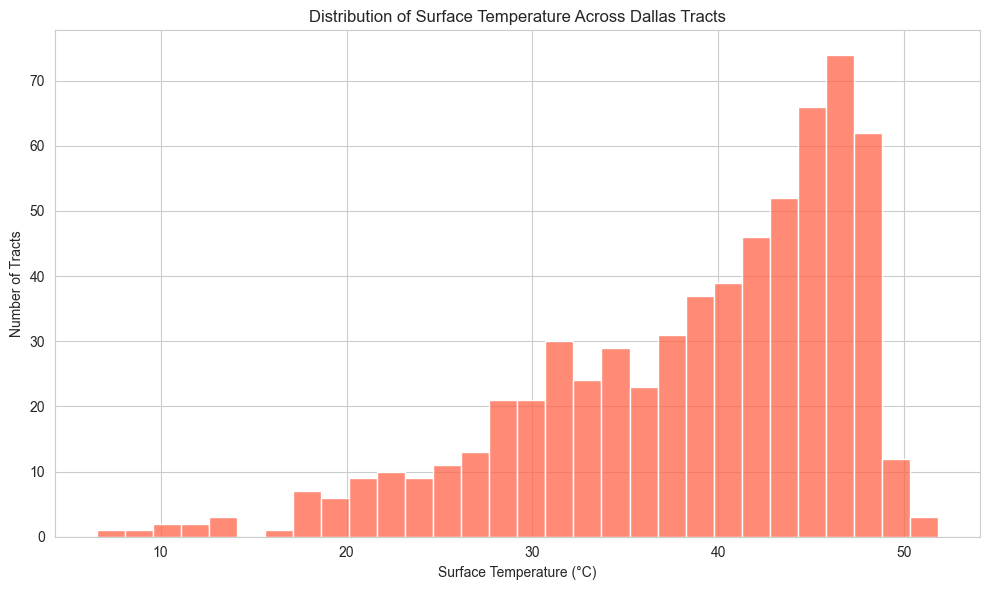

In [12]:
# set plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# plot 1 - LST distribution
plt.figure()
sns.histplot(master["lst_celsius"], bins=30, color="tomato")
plt.title("Distribution of Surface Temperature Across Dallas Tracts")
plt.xlabel("Surface Temperature (°C)")
plt.ylabel("Number of Tracts")
plt.tight_layout()
plt.show()

Plot 1 - Summary
The cool areas are most likely parks, lakes, or areas with lots of trees. Most of Dallas during late July is between 40-50 degrees celsius.

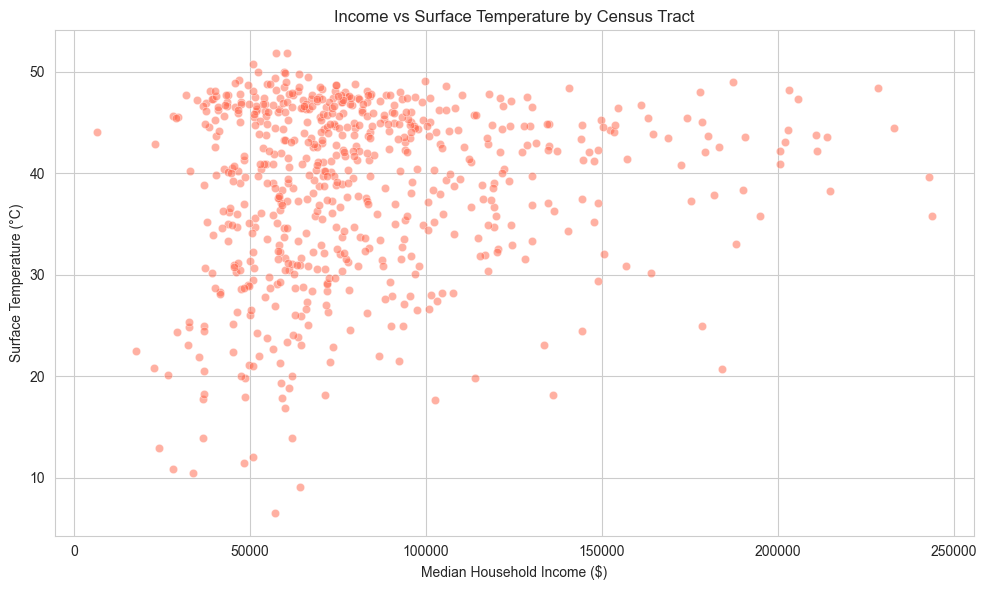

In [13]:
# plot 2 - income vs LST
plt.figure()
sns.scatterplot(data=master, x="median_income", y="lst_celsius", alpha=0.5, color="tomato")
plt.title("Income vs Surface Temperature by Census Tract")
plt.xlabel("Median Household Income ($)")
plt.ylabel("Surface Temperature (°C)")
plt.tight_layout()
plt.show()

Plot 2 - Summary
Lower income tracts tend to cluster at higher temperatures while higher income tracts spread more toward lower temperatures. Most tracts above 45 degrees celsius have a income below $75000. Higher income tracts rarely reach above 45 degrees celsius. The coolest tracts are most likely bodies of water and parks, which are spread out across land/neighborhoods.

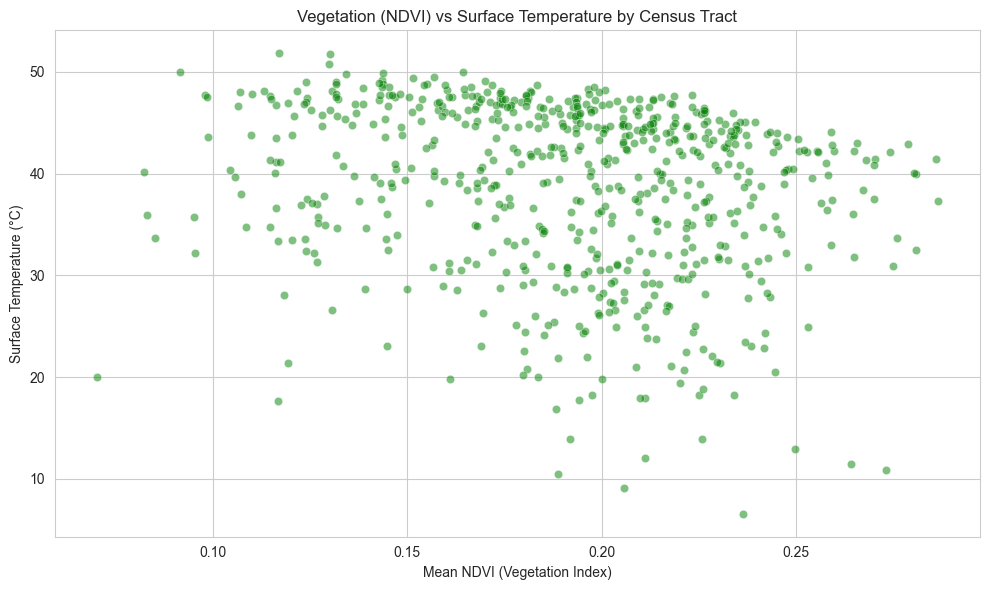

In [14]:
# plot 3 - NDVI vs LST
plt.figure()
sns.scatterplot(data=master, x="ndvi_mean", y="lst_celsius", alpha=0.5, color="green")
plt.title("Vegetation (NDVI) vs Surface Temperature by Census Tract")
plt.xlabel("Mean NDVI (Vegetation Index)")
plt.ylabel("Surface Temperature (°C)")
plt.tight_layout()
plt.show()

Plot 3 - Summary
There is a low strength negative correlation. Some points with a higher mean NDVI has a lower surface temperature, but there are also outlier (likely parks or bodies of water).

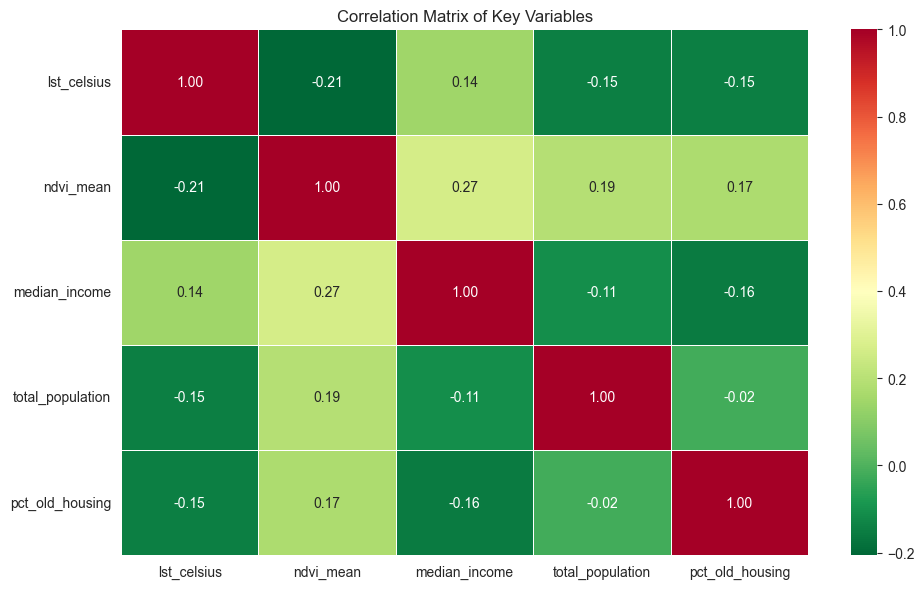

In [15]:
# plot 4 - correlation heatmap
plt.figure()
corr_cols = ["lst_celsius", "ndvi_mean", "median_income", 
             "total_population", "pct_old_housing"]
corr_matrix = master[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap="RdYlGn_r", 
            fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Key Variables")
plt.tight_layout()
plt.show()

Plot 4 - Summary
Surface temperature (LST) correlates with:
- ndvi_mean: -0.21, meaning more vegetation leads to cooler temperatures
- median income: 0.14, slightly higher income leads to slightly higher temperature
- total population: -0.15, denser areas are slighly cooler
- pct_old_housing: -0.15, older housing leads to a slightly cooler temperature

Income has a weak positive correlation with temperature, meaning that richer tracts are not necessarily cooler.

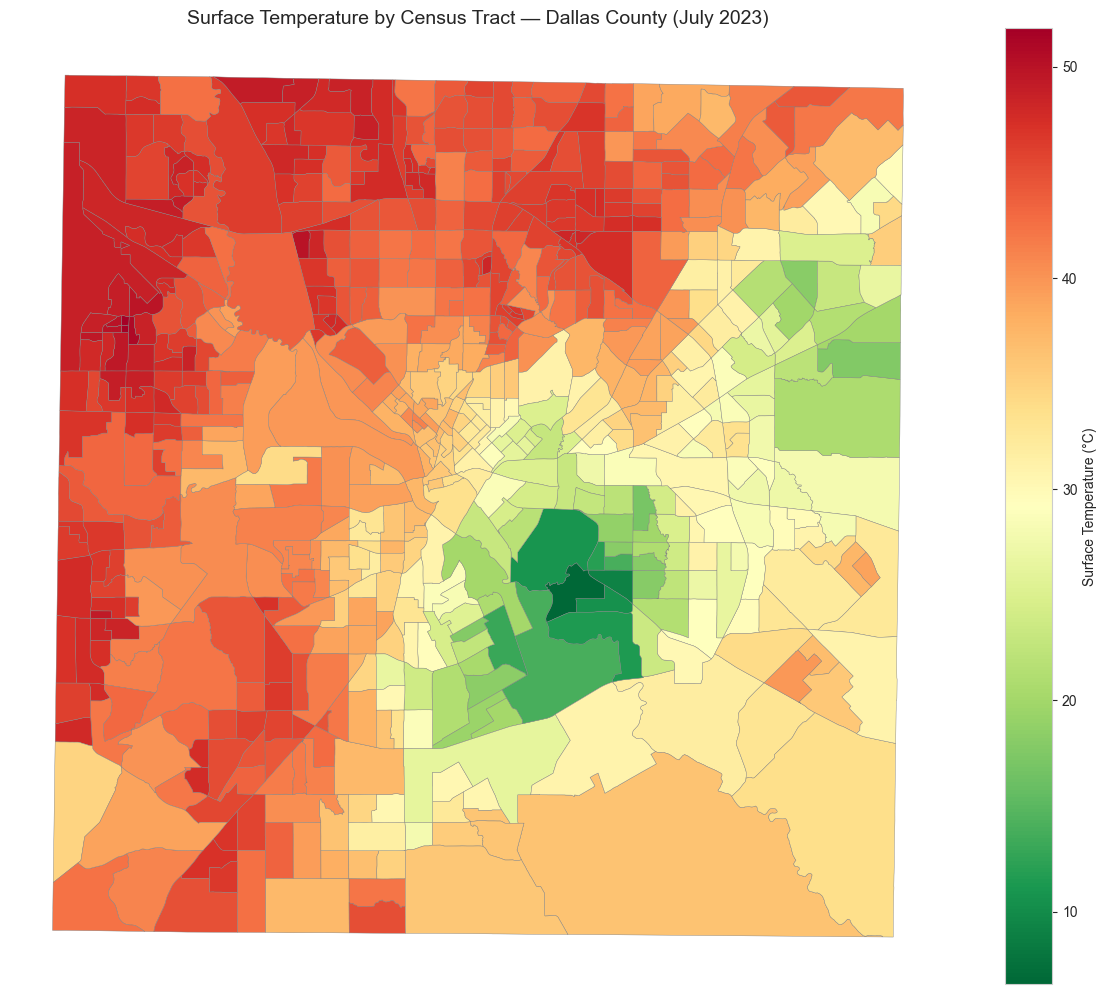

In [16]:
# plot 5 - map of surface temperature
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
master.plot(column="lst_celsius", cmap="RdYlGn_r", 
            linewidth=0.3, edgecolor="gray",
            legend=True, ax=ax,
            legend_kwds={"label": "Surface Temperature (°C)"})
ax.set_title("Surface Temperature by Census Tract — Dallas County (July 2023)", 
             fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

Plot 6 - Summary
The dark green area is White Rock Lake and its surrounding park, which is also one of Dallas' largest green spaces. The red areas in the North/top of the map and Southwest are industrial/commerical zones and dense urban zones with little to no vegetation.

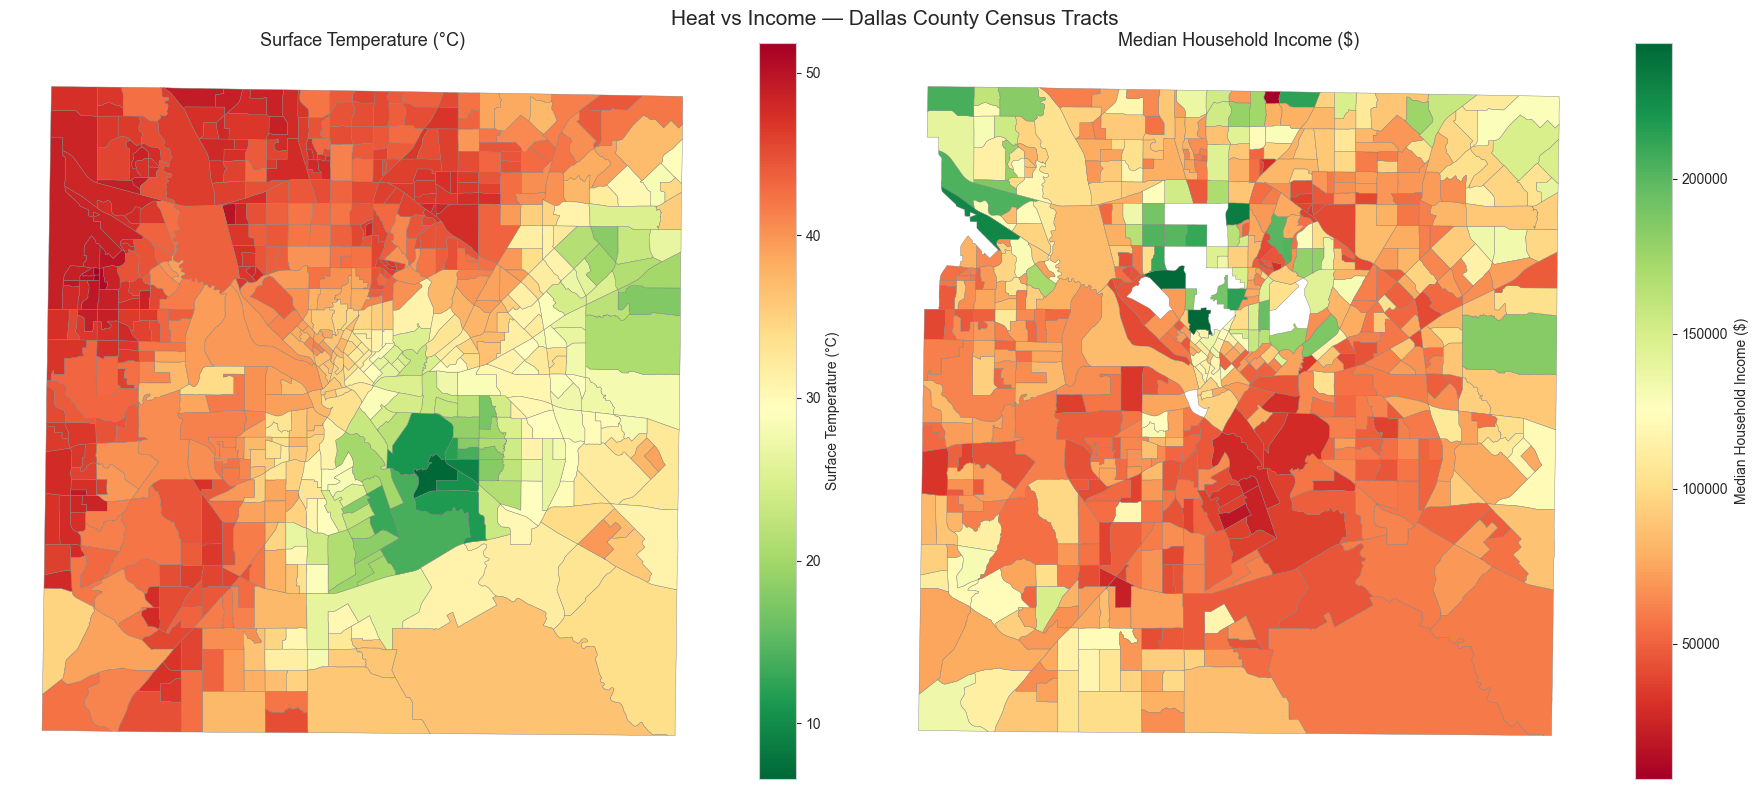

In [17]:
# plot 6 - side by side map of LST and income
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# LST map
master.plot(column="lst_celsius", cmap="RdYlGn_r",
            linewidth=0.3, edgecolor="gray",
            legend=True, ax=axes[0],
            legend_kwds={"label": "Surface Temperature (°C)"})
axes[0].set_title("Surface Temperature (°C)", fontsize=13)
axes[0].set_axis_off()

# income map
master.plot(column="median_income", cmap="RdYlGn",
            linewidth=0.3, edgecolor="gray",
            legend=True, ax=axes[1],
            legend_kwds={"label": "Median Household Income ($)"})
axes[1].set_title("Median Household Income ($)", fontsize=13)
axes[1].set_axis_off()

plt.suptitle("Heat vs Income — Dallas County Census Tracts", fontsize=15)
plt.tight_layout()
plt.show()

Comparison - Summary
The hottest areas in the west and northwest greatly overlap with the lowest income areas. The cooler green areas overlap with higher income areas. Lastly, downtown dallas shows a moderate temperature with a mix of income levels.

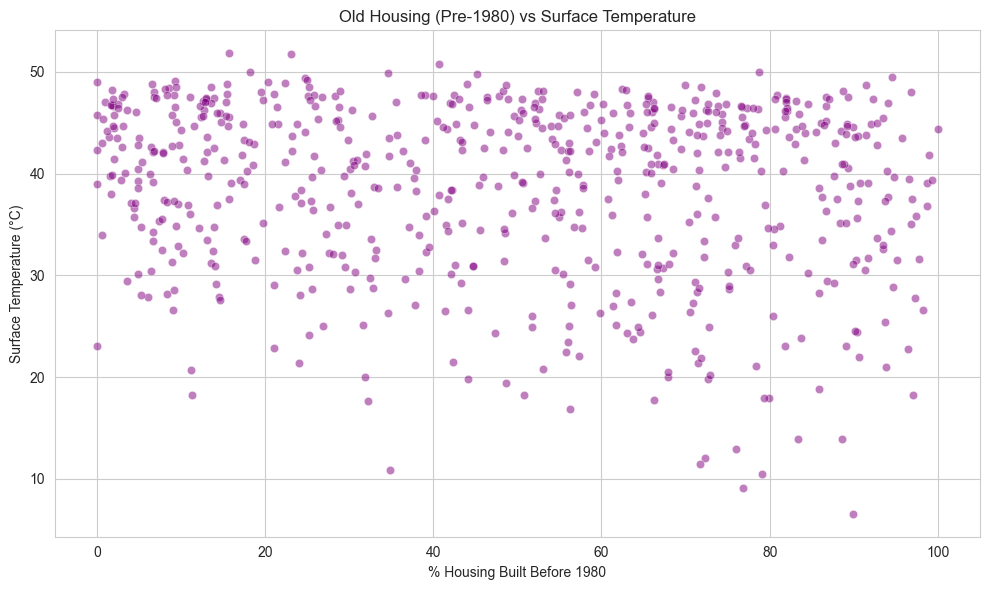

In [18]:
# plot 7 - old housing vs LST
plt.figure()
sns.scatterplot(data=master, x="pct_old_housing", y="lst_celsius", 
                alpha=0.5, color="purple")
plt.title("Old Housing (Pre-1980) vs Surface Temperature")
plt.xlabel("% Housing Built Before 1980")
plt.ylabel("Surface Temperature (°C)")
plt.tight_layout()
plt.show()

Plot 7 - Summary
There is not a strong pattern between old housing and temperature. This means old housing most likely does not affect surface temperature. However, this is still useful because older homes without good insulation or AC will suffer more with higher temperatures.